In [1]:
import pandas as pd
import numpy as np
from dep2pyodbc import dep2connection

pd.set_option("display.max_columns", None)

channel_crh = dep2connection("CRH")
channel_dwh_lisa = dep2connection("CRH_DWH")
cursor = channel_dwh_lisa.cursor()

pyodbc using windows
pyodbc using windows


In [2]:
baq = pd.read_csv('./csv/raw_data/decoded_baq.csv')
baq.head()

,CandidateID,InstanceID,itemId_norm,norm_1,norm_2,norm_3,norm_4,norm_5,itemId_ips,ips_1,ips_2,ips_3,ips_4,ips_5
0,109200,1,1,4,3,4,4,5,1,3,1,2,4,5
1,109200,1,1,5,5,5,5,5,1,2,4,5,3,1
2,109200,1,1,4,3,5,5,3,1,3,2,5,4,1
3,109200,1,1,2,5,5,4,4,1,1,4,5,3,2
4,109200,1,1,5,5,2,4,4,1,4,5,1,2,3


In [3]:
df_baq = baq
df_baq.rename(columns={
    'itemId_norm': 'NormItemID',
    'itemId_ips': 'IpsItemID',
    'norm_1': 'Norm1',
    'norm_2': 'Norm2',
    'norm_3': 'Norm3',
    'norm_4': 'Norm4',
    'norm_5': 'Norm5',
    'ips_1': 'Ips1',
    'ips_2': 'Ips2',
    'ips_3': 'Ips3',
    'ips_4': 'Ips4',
    'ips_5': 'Ips5',
    }, inplace=True)
df_baq['Test'] = 'BAQ'
df_baq.head()

,CandidateID,InstanceID,NormItemID,Norm1,Norm2,Norm3,Norm4,Norm5,IpsItemID,Ips1,Ips2,Ips3,Ips4,Ips5,Test
0,109200,1,1,4,3,4,4,5,1,3,1,2,4,5,BAQ
1,109200,1,1,5,5,5,5,5,1,2,4,5,3,1,BAQ
2,109200,1,1,4,3,5,5,3,1,3,2,5,4,1,BAQ
3,109200,1,1,2,5,5,4,4,1,1,4,5,3,2,BAQ
4,109200,1,1,5,5,2,4,4,1,4,5,1,2,3,BAQ


In [4]:
df_baq.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47039340 entries, 0 to 47039339
Data columns (total 15 columns):
 #   Column       Dtype 
---  ------       ----- 
 0   CandidateID  int64 
 1   InstanceID   int64 
 2   NormItemID   int64 
 3   Norm1        int64 
 4   Norm2        int64 
 5   Norm3        int64 
 6   Norm4        int64 
 7   Norm5        int64 
 8   IpsItemID    int64 
 9   Ips1         int64 
 10  Ips2         int64 
 11  Ips3         int64 
 12  Ips4         int64 
 13  Ips5         int64 
 14  Test         object
dtypes: int64(14), object(1)
memory usage: 5.3+ GB


## Basic cleaning

In [5]:
columns = ['Ips1', 'Ips2', 'Ips3', 'Ips4', 'Ips5', 'Norm1', 'Norm2', 'Norm3', 'Norm4', 'Norm5']

for col in columns:
    in_range = df_baq[col].isin([1, 2, 3, 4, 5]).all()
    if not in_range: 
        print(f"Some values in the {col} column do not fall in the permitted range.")
        df_baq = df_baq[df_baq[col].isin([1, 2, 3, 4, 5])]
    else: 
        print(f"All values in the {col} column fall in the permitted range.")

Some values in the Ips1 column do not fall in the permitted range.
Some values in the Ips2 column do not fall in the permitted range.
Some values in the Ips3 column do not fall in the permitted range.
Some values in the Ips4 column do not fall in the permitted range.
Some values in the Ips5 column do not fall in the permitted range.
Some values in the Norm1 column do not fall in the permitted range.
Some values in the Norm2 column do not fall in the permitted range.
Some values in the Norm3 column do not fall in the permitted range.
Some values in the Norm4 column do not fall in the permitted range.
Some values in the Norm5 column do not fall in the permitted range.


In [6]:
import itertools

numbers = [1, 2, 3, 4, 5]
permutations = list(itertools.permutations(numbers))
permutations_list = [list(perm) for perm in permutations]
permutations_list[0], permutations_list[-1]

([1, 2, 3, 4, 5], [5, 4, 3, 2, 1])

In [7]:
df_baq['combined_list'] = df_baq[['Norm1', 'Norm2', 'Norm3', 'Norm4', 'Norm5']].values.tolist()

In [8]:
df_baq = df_baq[df_baq['combined_list'].isin(permutations_list)]

In [9]:
df_baq.info()

<class 'pandas.core.frame.DataFrame'>
Index: 469183 entries, 272 to 47039309
Data columns (total 16 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   CandidateID    469183 non-null  int64 
 1   InstanceID     469183 non-null  int64 
 2   NormItemID     469183 non-null  int64 
 3   Norm1          469183 non-null  int64 
 4   Norm2          469183 non-null  int64 
 5   Norm3          469183 non-null  int64 
 6   Norm4          469183 non-null  int64 
 7   Norm5          469183 non-null  int64 
 8   IpsItemID      469183 non-null  int64 
 9   Ips1           469183 non-null  int64 
 10  Ips2           469183 non-null  int64 
 11  Ips3           469183 non-null  int64 
 12  Ips4           469183 non-null  int64 
 13  Ips5           469183 non-null  int64 
 14  Test           469183 non-null  object
 15  combined_list  469183 non-null  object
dtypes: int64(14), object(2)
memory usage: 60.9+ MB


In [10]:
df_baq.drop(columns=['combined_list'], inplace=True)
df_baq.head()

,CandidateID,InstanceID,NormItemID,Norm1,Norm2,Norm3,Norm4,Norm5,IpsItemID,Ips1,Ips2,Ips3,Ips4,Ips5,Test
272,103443,1,1,2,3,5,1,4,1,2,3,4,1,5,BAQ
563,103409,1,1,4,5,1,2,3,1,4,5,1,2,3,BAQ
1564,103372,1,1,4,5,2,1,3,1,5,4,2,1,3,BAQ
2280,102599,1,1,4,3,1,2,5,1,4,3,1,2,5,BAQ
2281,102599,1,1,1,2,5,4,3,1,2,1,5,4,3,BAQ


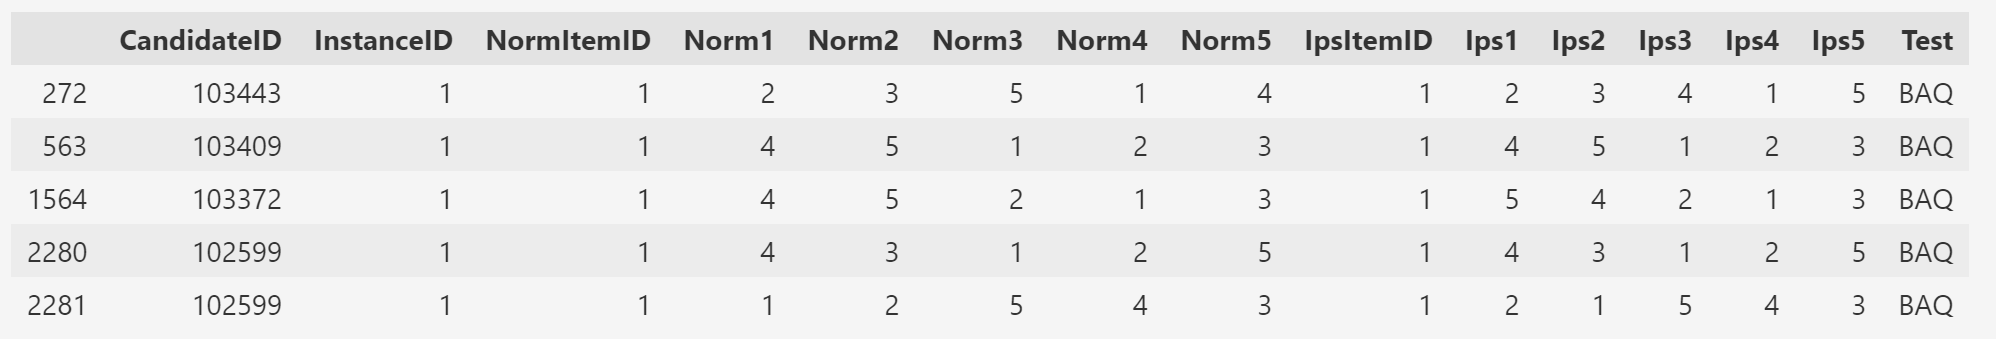

## Adding keys

### Candidates 

In [11]:
df_candidates_before_key = pd.read_sql("SELECT ID, CandidateID, InstanceID, CreatedDate, ModifiedDate, VersionNumber FROM CandidateResultBA51", channel_crh)
df_candidates_before_key.head()

C:\Users\monad\AppData\Local\Temp\ipykernel_5192\194759414.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_candidates_before_key = pd.read_sql("SELECT ID, CandidateID, InstanceID, CreatedDate, ModifiedDate, VersionNumber FROM CandidateResultBA51", channel_crh)


,ID,CandidateID,InstanceID,CreatedDate,ModifiedDate,VersionNumber
0,1,109200,1,2007-09-26 05:53:07.273,2007-09-26 06:19:55.357,None
1,2,109509,1,2007-09-26 07:50:25.090,2007-09-26 08:14:54.360,None
2,3,102984,1,2007-09-07 14:14:39.943,2007-09-07 14:43:52.920,None
3,4,103009,1,2007-09-07 14:21:42.093,2007-09-07 15:27:17.777,None
4,5,103443,1,2007-09-07 15:18:15.067,2007-09-07 15:51:42.010,None


In [12]:
df_baq = pd.merge(df_baq, df_candidates_before_key, on=["CandidateID", "InstanceID"], how="left")
df_baq.head()

,CandidateID,InstanceID,NormItemID,Norm1,Norm2,Norm3,Norm4,Norm5,IpsItemID,Ips1,Ips2,Ips3,Ips4,Ips5,Test,ID,CreatedDate,ModifiedDate,VersionNumber
0,103443,1,1,2,3,5,1,4,1,2,3,4,1,5,BAQ,5,2007-09-07 15:18:15.067,2007-09-07 15:51:42.010,None
1,103409,1,1,4,5,1,2,3,1,4,5,1,2,3,BAQ,10,2007-09-08 13:14:19.633,2007-09-08 14:16:52.570,None
2,103372,1,1,4,5,2,1,3,1,5,4,2,1,3,BAQ,27,2007-09-09 14:06:20.973,2007-09-09 15:56:22.907,None
3,102599,1,1,4,3,1,2,5,1,4,3,1,2,5,BAQ,39,2007-09-09 10:22:43.397,2007-09-09 11:37:57.277,None
4,102599,1,1,1,2,5,4,3,1,2,1,5,4,3,BAQ,39,2007-09-09 10:22:43.397,2007-09-09 11:37:57.277,None


In [13]:
dim_candidate = pd.read_sql("SELECT CandidateKey, ID, InstanceID FROM DimCandidate", channel_dwh_lisa)
dim_candidate.head()

C:\Users\monad\AppData\Local\Temp\ipykernel_5192\977585254.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  dim_candidate = pd.read_sql("SELECT CandidateKey, ID, InstanceID FROM DimCandidate", channel_dwh_lisa)


,CandidateKey,ID,InstanceID
0,14,1,4
1,22,2,2
2,23,2,3
3,24,2,4
4,32,3,2


In [14]:
df_baq = pd.merge(df_baq, dim_candidate, left_on=["CandidateID", "InstanceID"], right_on=["ID", "InstanceID"], how="left")
df_baq.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 469187 entries, 0 to 469186
Data columns (total 21 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   CandidateID    469187 non-null  int64         
 1   InstanceID     469187 non-null  int64         
 2   NormItemID     469187 non-null  int64         
 3   Norm1          469187 non-null  int64         
 4   Norm2          469187 non-null  int64         
 5   Norm3          469187 non-null  int64         
 6   Norm4          469187 non-null  int64         
 7   Norm5          469187 non-null  int64         
 8   IpsItemID      469187 non-null  int64         
 9   Ips1           469187 non-null  int64         
 10  Ips2           469187 non-null  int64         
 11  Ips3           469187 non-null  int64         
 12  Ips4           469187 non-null  int64         
 13  Ips5           469187 non-null  int64         
 14  Test           469187 non-null  object        
 15  

In [15]:
df_baq.drop(columns=["ID_y", "CandidateID"], inplace=True)
df_baq.rename(columns={"ID_x": "TestID"}, inplace=True)
df_baq.head()

,InstanceID,NormItemID,Norm1,Norm2,Norm3,Norm4,Norm5,IpsItemID,Ips1,Ips2,Ips3,Ips4,Ips5,Test,TestID,CreatedDate,ModifiedDate,VersionNumber,CandidateKey
0,1,1,2,3,5,1,4,1,2,3,4,1,5,BAQ,5,2007-09-07 15:18:15.067,2007-09-07 15:51:42.010,None,1034431
1,1,1,4,5,1,2,3,1,4,5,1,2,3,BAQ,10,2007-09-08 13:14:19.633,2007-09-08 14:16:52.570,None,1034091
2,1,1,4,5,2,1,3,1,5,4,2,1,3,BAQ,27,2007-09-09 14:06:20.973,2007-09-09 15:56:22.907,None,1033721
3,1,1,4,3,1,2,5,1,4,3,1,2,5,BAQ,39,2007-09-09 10:22:43.397,2007-09-09 11:37:57.277,None,1025991
4,1,1,1,2,5,4,3,1,2,1,5,4,3,BAQ,39,2007-09-09 10:22:43.397,2007-09-09 11:37:57.277,None,1025991


### Dates

In [16]:
df_dates = pd.read_sql("SELECT DateKey, Date FROM DimDate", channel_dwh_lisa)
df_dates.head()

C:\Users\monad\AppData\Local\Temp\ipykernel_5192\594440161.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_dates = pd.read_sql("SELECT DateKey, Date FROM DimDate", channel_dwh_lisa)


,DateKey,Date
0,20110101,2011-01-01
1,20110102,2011-01-02
2,20110103,2011-01-03
3,20110104,2011-01-04
4,20110105,2011-01-05


In [17]:
df_baq["CreatedDate"] = pd.to_datetime(df_baq["CreatedDate"]).dt.date

In [18]:
df_baq.head()

,InstanceID,NormItemID,Norm1,Norm2,Norm3,Norm4,Norm5,IpsItemID,Ips1,Ips2,Ips3,Ips4,Ips5,Test,TestID,CreatedDate,ModifiedDate,VersionNumber,CandidateKey
0,1,1,2,3,5,1,4,1,2,3,4,1,5,BAQ,5,2007-09-07,2007-09-07 15:51:42.010,None,1034431
1,1,1,4,5,1,2,3,1,4,5,1,2,3,BAQ,10,2007-09-08,2007-09-08 14:16:52.570,None,1034091
2,1,1,4,5,2,1,3,1,5,4,2,1,3,BAQ,27,2007-09-09,2007-09-09 15:56:22.907,None,1033721
3,1,1,4,3,1,2,5,1,4,3,1,2,5,BAQ,39,2007-09-09,2007-09-09 11:37:57.277,None,1025991
4,1,1,1,2,5,4,3,1,2,1,5,4,3,BAQ,39,2007-09-09,2007-09-09 11:37:57.277,None,1025991


In [19]:
# df_baq.sort_values(by='CreatedDate').head()

In [20]:
df_baq = pd.merge(df_baq, df_dates, left_on="CreatedDate", right_on="Date", how="left")
df_baq.drop(columns=["Date", "CreatedDate"], inplace=True)
df_baq.rename(columns={"DateKey": "CreatedDateKey"}, inplace=True)

In [21]:
df_baq["ModifiedDate"] = pd.to_datetime(df_baq["ModifiedDate"]).dt.date
df_baq = pd.merge(df_baq, df_dates, left_on="ModifiedDate", right_on="Date", how="left")
df_baq.drop(columns=["Date", "ModifiedDate"], inplace=True)
df_baq.rename(columns={"DateKey": "ModifiedDateKey"}, inplace=True)

In [22]:
df_baq.head()

,InstanceID,NormItemID,Norm1,Norm2,Norm3,Norm4,Norm5,IpsItemID,Ips1,Ips2,Ips3,Ips4,Ips5,Test,TestID,VersionNumber,CandidateKey,CreatedDateKey,ModifiedDateKey
0,1,1,2,3,5,1,4,1,2,3,4,1,5,BAQ,5,None,1034431,NaN,NaN
1,1,1,4,5,1,2,3,1,4,5,1,2,3,BAQ,10,None,1034091,NaN,NaN
2,1,1,4,5,2,1,3,1,5,4,2,1,3,BAQ,27,None,1033721,NaN,NaN
3,1,1,4,3,1,2,5,1,4,3,1,2,5,BAQ,39,None,1025991,NaN,NaN
4,1,1,1,2,5,4,3,1,2,1,5,4,3,BAQ,39,None,1025991,NaN,NaN


### Next TestKey available

In [23]:
df_test_paq = pd.read_csv('../decoded_data/PAQ/FactTest.csv')
df_test_paq.head()

,Test,CandidateKey,CreatedDateKey,VersionNumber,TestKey
0,PAQ,38114181,20190123,v1.0,166962
1,PAQ,38046331,20190110,v1.0,166963
2,PAQ,38114191,20190128,v1.0,166964
3,PAQ,38201141,20190206,v1.0,166965
4,PAQ,38337341,20190227,v1.0,166966


In [24]:
max_key = df_test_paq.TestKey.max()
max_key

172547

## FactTest

In [25]:
df_test = df_baq[["TestID", "Test", "CandidateKey", "CreatedDateKey", "ModifiedDateKey", "VersionNumber"]]

df_test.drop_duplicates(inplace=True)
df_test.reset_index(inplace=True, drop=True)
df_test["TestKey"] = df_test.index + max_key + 1

df_test.head()

C:\Users\monad\AppData\Local\Temp\ipykernel_5192\2380037343.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test.drop_duplicates(inplace=True)
C:\Users\monad\AppData\Local\Temp\ipykernel_5192\2380037343.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test["TestKey"] = df_test.index + max_key + 1


,TestID,Test,CandidateKey,CreatedDateKey,ModifiedDateKey,VersionNumber,TestKey
0,5,BAQ,1034431,NaN,NaN,None,172548
1,10,BAQ,1034091,NaN,NaN,None,172549
2,27,BAQ,1033721,NaN,NaN,None,172550
3,39,BAQ,1025991,NaN,NaN,None,172551
4,42,BAQ,1034191,NaN,NaN,None,172552


## FactQuestionBAQ

In [26]:
df_question = df_baq.drop(columns=["CandidateKey", "CreatedDateKey", "ModifiedDateKey", "VersionNumber"])
df_question["QuestionKey"] = df_question.index + 1
df_question.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 469187 entries, 0 to 469186
Data columns (total 16 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   InstanceID   469187 non-null  int64 
 1   NormItemID   469187 non-null  int64 
 2   Norm1        469187 non-null  int64 
 3   Norm2        469187 non-null  int64 
 4   Norm3        469187 non-null  int64 
 5   Norm4        469187 non-null  int64 
 6   Norm5        469187 non-null  int64 
 7   IpsItemID    469187 non-null  int64 
 8   Ips1         469187 non-null  int64 
 9   Ips2         469187 non-null  int64 
 10  Ips3         469187 non-null  int64 
 11  Ips4         469187 non-null  int64 
 12  Ips5         469187 non-null  int64 
 13  Test         469187 non-null  object
 14  TestID       469187 non-null  int64 
 15  QuestionKey  469187 non-null  int64 
dtypes: int64(15), object(1)
memory usage: 57.3+ MB


In [27]:
df_question.head()

,InstanceID,NormItemID,Norm1,Norm2,Norm3,Norm4,Norm5,IpsItemID,Ips1,Ips2,Ips3,Ips4,Ips5,Test,TestID,QuestionKey
0,1,1,2,3,5,1,4,1,2,3,4,1,5,BAQ,5,1
1,1,1,4,5,1,2,3,1,4,5,1,2,3,BAQ,10,2
2,1,1,4,5,2,1,3,1,5,4,2,1,3,BAQ,27,3
3,1,1,4,3,1,2,5,1,4,3,1,2,5,BAQ,39,4
4,1,1,1,2,5,4,3,1,2,1,5,4,3,BAQ,39,5


In [28]:
len(df_question)

469187

In [29]:
chunk_size = 100_000
chunks = []
c = 0
for chunk_start in range(0, len(df_question), chunk_size):
    c += 1
    chunk_end = chunk_start + chunk_size
    chunk = df_question.iloc[chunk_start:chunk_end]
    chunk_result = pd.merge(chunk, df_test[["TestKey", "TestID"]], on="TestID", how="left")
    chunks.append(chunk_result)
    if c % 10 == 0: print(f"chuck {c} complete")

In [30]:
df_result = pd.concat(chunks)

In [31]:
# # Als je geen memory error krijgt kan je deze doen 
# df_question = pd.merge(df_question, df_test[["TestKey", "TestID"]], on="TestID", how="left")

In [32]:
df_result.head()

,InstanceID,NormItemID,Norm1,Norm2,Norm3,Norm4,Norm5,IpsItemID,Ips1,Ips2,Ips3,Ips4,Ips5,Test,TestID,QuestionKey,TestKey
0,1,1,2,3,5,1,4,1,2,3,4,1,5,BAQ,5,1,172548
1,1,1,4,5,1,2,3,1,4,5,1,2,3,BAQ,10,2,172549
2,1,1,4,5,2,1,3,1,5,4,2,1,3,BAQ,27,3,172550
3,1,1,4,3,1,2,5,1,4,3,1,2,5,BAQ,39,4,172551
4,1,1,1,2,5,4,3,1,2,1,5,4,3,BAQ,39,5,172551


In [33]:
df_question.head()

,InstanceID,NormItemID,Norm1,Norm2,Norm3,Norm4,Norm5,IpsItemID,Ips1,Ips2,Ips3,Ips4,Ips5,Test,TestID,QuestionKey
0,1,1,2,3,5,1,4,1,2,3,4,1,5,BAQ,5,1
1,1,1,4,5,1,2,3,1,4,5,1,2,3,BAQ,10,2
2,1,1,4,5,2,1,3,1,5,4,2,1,3,BAQ,27,3
3,1,1,4,3,1,2,5,1,4,3,1,2,5,BAQ,39,4
4,1,1,1,2,5,4,3,1,2,1,5,4,3,BAQ,39,5


In [34]:
# chunk_size = 100_000
# chunks = []
# c = 0
# for chunk_start in range(0, len(df_question), chunk_size):
#     c += 1
#     chunk_end = chunk_start + chunk_size
#     chunk = df_question.iloc[chunk_start:chunk_end]

#     # actions
#     # chunk = chunk.set_index('QuestionKey')
#     chunk.drop(columns=["TestID"], inplace=True)

#     # keep chunks 
#     chunks.append(chunk_result)
#     if c % 20 == 0: print(f"chuck {c} complete")

In [35]:
df_question = df_result

df_question.head()

,InstanceID,NormItemID,Norm1,Norm2,Norm3,Norm4,Norm5,IpsItemID,Ips1,Ips2,Ips3,Ips4,Ips5,Test,TestID,QuestionKey,TestKey
0,1,1,2,3,5,1,4,1,2,3,4,1,5,BAQ,5,1,172548
1,1,1,4,5,1,2,3,1,4,5,1,2,3,BAQ,10,2,172549
2,1,1,4,5,2,1,3,1,5,4,2,1,3,BAQ,27,3,172550
3,1,1,4,3,1,2,5,1,4,3,1,2,5,BAQ,39,4,172551
4,1,1,1,2,5,4,3,1,2,1,5,4,3,BAQ,39,5,172551


In [36]:
df_question.drop(columns=['TestID', 'InstanceID'], inplace=True)

In [37]:
# df_question = pd.concat(chunks)
df_question.head()

,NormItemID,Norm1,Norm2,Norm3,Norm4,Norm5,IpsItemID,Ips1,Ips2,Ips3,Ips4,Ips5,Test,QuestionKey,TestKey
0,1,2,3,5,1,4,1,2,3,4,1,5,BAQ,1,172548
1,1,4,5,1,2,3,1,4,5,1,2,3,BAQ,2,172549
2,1,4,5,2,1,3,1,5,4,2,1,3,BAQ,3,172550
3,1,4,3,1,2,5,1,4,3,1,2,5,BAQ,4,172551
4,1,1,2,5,4,3,1,2,1,5,4,3,BAQ,5,172551


In [38]:
df_test.drop(columns=["TestID"], inplace=True)

C:\Users\monad\AppData\Local\Temp\ipykernel_5192\1141659774.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test.drop(columns=["TestID"], inplace=True)


## To csv 

In [39]:
df_test.to_csv('../decoded_data/BA51/FactTest.csv', index=False)
df_question.to_csv('../decoded_data/BA51/FactQuestionBAQ.csv', index=False)